# 📚 Personalized AI Book Recommender System

Welcome to the **AI-powered Book Recommender** built using **Keras Autoencoders**, designed to suggest personalized book recommendations based on user preferences and collaborative filtering.

This notebook outlines the **entire ML pipeline** behind the deployed Streamlit app — from data preprocessing, model training, and evaluation to prediction generation.

---

### 🔧 Technologies Used
- Deep Learning (Keras, Autoencoders)
- Collaborative Filtering
- NumPy, Pandas, Matplotlib
- Data Encoding & Recommendation Logic

---

### 🧠 What This Notebook Does
- Loads and processes user-book rating data  
- Builds and trains a neural autoencoder  
- Generates predictions on unseen user-book combinations  
- Saves final outputs (`.npy`) for real-time inference in the Streamlit UI  

---

### ⚠️ Note
> Some code cells are **intentionally commented** to **avoid re-running heavy operations** (like training or generating predictions) every time.  
> If you’d like to execute those steps manually, feel free to **uncomment and run them**.

---

### 👨‍💻 Created by:
**Pranit Saundankar**  
📍 AI/ML Enthusiast | Data Science Explorer | 

---

Let’s dive in! 🚀


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
import sklearn.preprocessing

In [13]:
import keras

In [14]:
books = pd.read_csv(r"D:\PranitCode\Projects\Book-Recommender-AI-Model-App\books.csv")
tags = pd.read_csv(r"D:\PranitCode\Projects\Book-Recommender-AI-Model-App\tags.csv")
book_tags = pd.read_csv(r"D:\PranitCode\Projects\Book-Recommender-AI-Model-App\book_tags.csv")
ratings = pd.read_csv(r"D:\PranitCode\Projects\Book-Recommender-AI-Model-App\\ratings.csv")
to_read = pd.read_csv(r"D:\PranitCode\Projects\Book-Recommender-AI-Model-App\\to_read.csv")


In [15]:
# Merge tags with tag names
tag_names = tags.merge(book_tags, on='tag_id')

# Count most common tags per book
tag_counts = tag_names.groupby(['goodreads_book_id', 'tag_name'])['count'].sum().reset_index()

# Get top tag (genre) per book
top_tags = tag_counts.sort_values(['goodreads_book_id', 'count'], ascending=[True, False])
top_genres = top_tags.groupby('goodreads_book_id').first().reset_index()
top_genres.rename(columns={'tag_name': 'genre'}, inplace=True)

# Merge genre into books
books_with_genres = books.merge(top_genres, on='goodreads_book_id', how='left')


In [16]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   book_id                    10000 non-null  int64  
 1   goodreads_book_id          10000 non-null  int64  
 2   best_book_id               10000 non-null  int64  
 3   work_id                    10000 non-null  int64  
 4   books_count                10000 non-null  int64  
 5   isbn                       9300 non-null   object 
 6   isbn13                     9415 non-null   float64
 7   authors                    10000 non-null  object 
 8   original_publication_year  9979 non-null   float64
 9   original_title             9415 non-null   object 
 10  title                      10000 non-null  object 
 11  language_code              8916 non-null   object 
 12  average_rating             10000 non-null  float64
 13  ratings_count              10000 non-null  int6

In [17]:
books.drop(columns=["image_url","small_image_url"],inplace=True,errors="ignore")

In [18]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   book_id                    10000 non-null  int64  
 1   goodreads_book_id          10000 non-null  int64  
 2   best_book_id               10000 non-null  int64  
 3   work_id                    10000 non-null  int64  
 4   books_count                10000 non-null  int64  
 5   isbn                       9300 non-null   object 
 6   isbn13                     9415 non-null   float64
 7   authors                    10000 non-null  object 
 8   original_publication_year  9979 non-null   float64
 9   original_title             9415 non-null   object 
 10  title                      10000 non-null  object 
 11  language_code              8916 non-null   object 
 12  average_rating             10000 non-null  float64
 13  ratings_count              10000 non-null  int6

In [19]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5976479 entries, 0 to 5976478
Data columns (total 3 columns):
 #   Column   Dtype
---  ------   -----
 0   user_id  int64
 1   book_id  int64
 2   rating   int64
dtypes: int64(3)
memory usage: 136.8 MB


In [20]:
books.drop_duplicates(inplace=True)

In [21]:
ratings.drop_duplicates(subset=["user_id","book_id"],inplace=True)

In [22]:
#book_tags.drop_duplicates(inplace=True)
tags.drop_duplicates(inplace=True)
to_read.drop_duplicates(inplace=True)

In [23]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5976479 entries, 0 to 5976478
Data columns (total 3 columns):
 #   Column   Dtype
---  ------   -----
 0   user_id  int64
 1   book_id  int64
 2   rating   int64
dtypes: int64(3)
memory usage: 136.8 MB


C:\Users\AJAY KUMAR\AppData\Local\Temp\ipykernel_9544\4230213788.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_users.index.astype(str), y=top_users.values, palette="coolwarm")


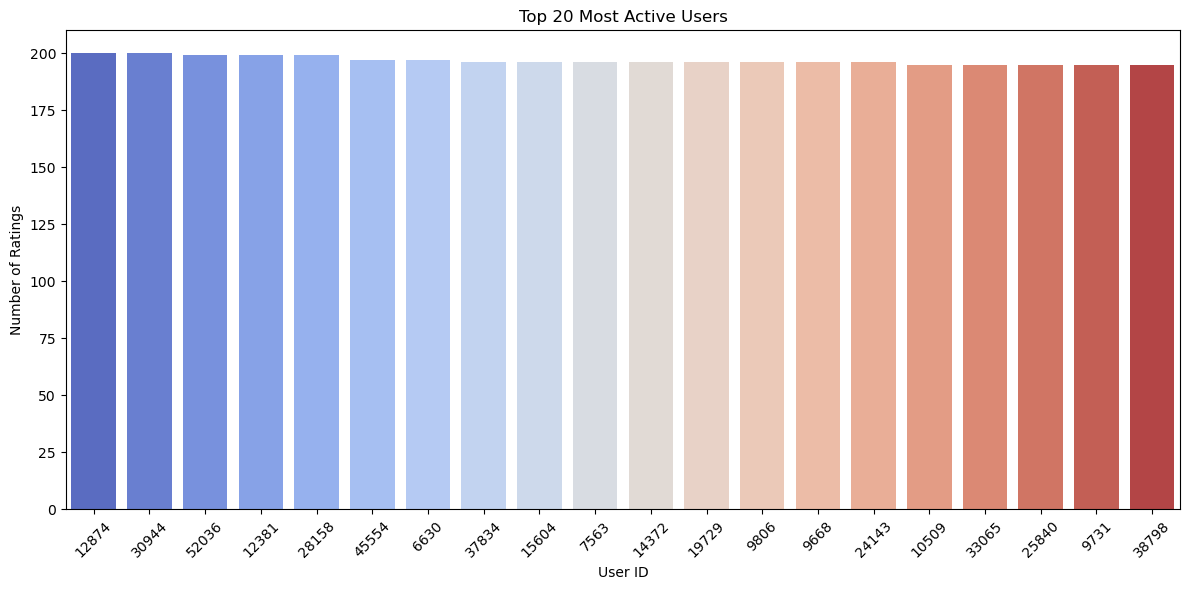

In [26]:
top_users = ratings['user_id'].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_users.index.astype(str), y=top_users.values, palette="coolwarm")
plt.title("Top 20 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
books.isnull().sum()

book_id                         0
goodreads_book_id               0
best_book_id                    0
work_id                         0
books_count                     0
isbn                          700
isbn13                        585
authors                         0
original_publication_year      21
original_title                585
title                           0
language_code                1084
average_rating                  0
ratings_count                   0
work_ratings_count              0
work_text_reviews_count         0
ratings_1                       0
ratings_2                       0
ratings_3                       0
ratings_4                       0
ratings_5                       0
dtype: int64

In [16]:
books.drop(columns=["isbn","isbn13","original_title"],inplace=True,errors="ignore")

In [17]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   book_id                    10000 non-null  int64  
 1   goodreads_book_id          10000 non-null  int64  
 2   best_book_id               10000 non-null  int64  
 3   work_id                    10000 non-null  int64  
 4   books_count                10000 non-null  int64  
 5   authors                    10000 non-null  object 
 6   original_publication_year  9979 non-null   float64
 7   title                      10000 non-null  object 
 8   language_code              8916 non-null   object 
 9   average_rating             10000 non-null  float64
 10  ratings_count              10000 non-null  int64  
 11  work_ratings_count         10000 non-null  int64  
 12  work_text_reviews_count    10000 non-null  int64  
 13  ratings_1                  10000 non-null  int6

In [18]:
books.isnull().sum()

book_id                         0
goodreads_book_id               0
best_book_id                    0
work_id                         0
books_count                     0
authors                         0
original_publication_year      21
title                           0
language_code                1084
average_rating                  0
ratings_count                   0
work_ratings_count              0
work_text_reviews_count         0
ratings_1                       0
ratings_2                       0
ratings_3                       0
ratings_4                       0
ratings_5                       0
dtype: int64

In [19]:
books.dropna(subset=["original_publication_year"], inplace=True)


In [20]:
books["language_code"].fillna("unk", inplace=True)


C:\Users\AJAY KUMAR\AppData\Local\Temp\ipykernel_10208\1496005322.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  books["language_code"].fillna("unk", inplace=True)


In [21]:
books.isnull().sum()

book_id                      0
goodreads_book_id            0
best_book_id                 0
work_id                      0
books_count                  0
authors                      0
original_publication_year    0
title                        0
language_code                0
average_rating               0
ratings_count                0
work_ratings_count           0
work_text_reviews_count      0
ratings_1                    0
ratings_2                    0
ratings_3                    0
ratings_4                    0
ratings_5                    0
dtype: int64

In [22]:
ratings.isnull().sum()

user_id    0
book_id    0
rating     0
dtype: int64

In [23]:
tags.isnull().sum()

tag_id      0
tag_name    0
dtype: int64

In [24]:
book_tags.isnull().sum()

goodreads_book_id    0
tag_id               0
count                0
dtype: int64

In [25]:
to_read.isnull().sum()

user_id    0
book_id    0
dtype: int64

In [71]:
#merged_df = ratings.merge(books_with_genres, on="book_id")
#merged_df.to_csv("merged_data.csv", index=False)


In [72]:
merged_df = pd.read_csv("merged_data.csv")

In [73]:
merged_df.head()

,user_id,book_id,rating,goodreads_book_id,best_book_id,work_id,books_count,authors,original_publication_year,title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,genre,count
0,1,258,5,1232,1232,3209783,279,"Carlos Ruiz Zafón, Lucia Graves",2001.0,The Shadow of the Wind (The Cemetery of Forgot...,...,263685,317554,24652,4789,11769,42214,101612,157170,to-read,190891
1,2,4081,4,231,231,1005335,53,Tom Wolfe,2004.0,I am Charlotte Simmons,...,19293,21580,1891,1481,2886,6557,6890,3766,to-read,5250
2,2,260,5,4865,4865,2370171,353,Dale Carnegie,1936.0,How to Win Friends and Influence People,...,282623,305437,7909,6734,13880,50529,94743,139551,non-fiction,2510
3,2,9296,5,4887,4887,821815,75,"Alice Miller, Ruth Ward",1979.0,The Drama of the Gifted Child: The Search for ...,...,9563,10830,537,189,490,2025,3548,4578,to-read,348
4,2,2318,3,998,998,5210,43,"Thomas J. Stanley, William D. Danko",1995.0,The Millionaire Next Door: The Surprising Secr...,...,43937,46748,2049,645,2318,10382,16665,16738,to-read,37679


In [29]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5970537 entries, 0 to 5970536
Data columns (total 20 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   user_id                    int64  
 1   book_id                    int64  
 2   rating                     int64  
 3   goodreads_book_id          int64  
 4   best_book_id               int64  
 5   work_id                    int64  
 6   books_count                int64  
 7   authors                    object 
 8   original_publication_year  float64
 9   title                      object 
 10  language_code              object 
 11  average_rating             float64
 12  ratings_count              int64  
 13  work_ratings_count         int64  
 14  work_text_reviews_count    int64  
 15  ratings_1                  int64  
 16  ratings_2                  int64  
 17  ratings_3                  int64  
 18  ratings_4                  int64  
 19  ratings_5                  int64  
dtypes:

In [30]:
# Step 1: Keep users who rated at least 5 books
user_thresh = 10
active_users = merged_df['user_id'].value_counts()
valid_users = active_users[active_users >= user_thresh].index

In [31]:
# Step 2: Keep books that received at least 30 ratings
book_thresh = 50
popular_books = merged_df['book_id'].value_counts()
valid_books = popular_books[popular_books >= book_thresh].index

In [32]:
# Step 3: Apply filters
filtered_df = merged_df[
    (merged_df['user_id'].isin(valid_users)) &
    (merged_df['book_id'].isin(valid_books))
]

In [33]:
print("Users:", filtered_df['user_id'].nunique())
print("Books:", filtered_df['book_id'].nunique())
print("Ratings:", filtered_df.shape[0])

Users: 53424
Books: 9970
Ratings: 5970243


In [66]:
from scipy.sparse import csr_matrix

df = merged_df

#morefilters:
df = df.merge(books[['book_id', 'authors']], on='book_id', how='left')

df['user_index'] = df['user_id'].astype("category").cat.codes
df['book_index'] = df['book_id'].astype("category").cat.codes

ratings_sparse = csr_matrix(
    (df['rating'], (df['user_index'], df['book_index']))
)


In [75]:
def filter_by_genre(df, genre, top_n=5):
    return df[df['genre'].str.contains(genre, case=False, na=False)] \
             .drop_duplicates(subset=['book_id']) \
             .sort_values(by='average_rating', ascending=False).head(top_n)

def filter_by_author(df, author, top_n=5):
    return df[df['authors'].str.contains(author, case=False, na=False)] \
             .drop_duplicates(subset=['book_id']) \
             .sort_values(by='average_rating', ascending=False).head(top_n)

def filter_by_rating(df, min_rating=4.0, top_n=5):
    return df[df['average_rating'] >= min_rating] \
             .drop_duplicates(subset=['book_id']) \
             .sort_values(by='average_rating', ascending=False).head(top_n)

def filter_by_genre_and_rating(df, genre, min_rating=4.0, top_n=5):
    return df[
        (df['genre'].str.contains(genre, case=False, na=False)) &
        (df['average_rating'] >= min_rating)
    ].drop_duplicates(subset=['book_id']) \
     .sort_values(by='average_rating', ascending=False).head(top_n)

def filter_by_author_and_genre(df, author, genre, top_n=5):
    return df[
        (df['authors'].str.contains(author, case=False, na=False)) &
        (df['genre'].str.contains(genre, case=False, na=False))
    ].drop_duplicates(subset=['book_id']) \
     .sort_values(by='average_rating', ascending=False).head(top_n)

In [78]:
def recommend_by_genre(genre, df=merged_df, top_n=5):
    filtered = df[df['genre'].str.contains(genre, case=False, na=False)]
    return filtered[['title', 'authors', 'average_rating']].drop_duplicates().sort_values(by='average_rating', ascending=False).head(top_n)

def recommend_by_author(author, df=merged_df, top_n=5):
    filtered = df[df['authors'].str.contains(author, case=False, na=False)]
    return filtered[['title', 'authors', 'average_rating']].drop_duplicates().sort_values(by='average_rating', ascending=False).head(top_n)

def recommend_by_rating(min_rating=4.0, df=merged_df, top_n=5):
    filtered = df[df['average_rating'] >= min_rating]
    return filtered[['title', 'authors', 'average_rating']].drop_duplicates().sort_values(by='average_rating', ascending=False).head(top_n)

def recommend_by_genre_and_rating(genre, min_rating=4.0, df=merged_df, top_n=5):
    filtered = df[
        (df['genre'].str.contains(genre, case=False, na=False)) &
        (df['average_rating'] >= min_rating)
    ]
    return filtered[['title', 'authors', 'average_rating']].drop_duplicates().sort_values(by='average_rating', ascending=False).head(top_n)


In [79]:
def recommend_by_author_and_genre(author, genre, df=merged_df, top_n=5):
    filtered = df[
        (df['authors'].str.contains(author, case=False, na=False)) &
        (df['genre'].str.contains(genre, case=False, na=False))
    ]
    return filtered[['title', 'authors', 'average_rating']] \
           .drop_duplicates().sort_values(by='average_rating', ascending=False).head(top_n)

def recommend_by_author_and_rating(author, min_rating=4.0, df=merged_df, top_n=5):
    filtered = df[
        (df['authors'].str.contains(author, case=False, na=False)) &
        (df['average_rating'] >= min_rating)
    ]
    return filtered[['title', 'authors', 'average_rating']] \
           .drop_duplicates().sort_values(by='average_rating', ascending=False).head(top_n)

def recommend_by_author_genre_rating(author, genre, min_rating=4.0, df=merged_df, top_n=5):
    filtered = df[
        (df['authors'].str.contains(author, case=False, na=False)) &
        (df['genre'].str.contains(genre, case=False, na=False)) &
        (df['average_rating'] >= min_rating)
    ]
    return filtered[['title', 'authors', 'average_rating']] \
           .drop_duplicates().sort_values(by='average_rating', ascending=False).head(top_n)


In [35]:
df.shape

(5970537, 22)

In [36]:
ratings_sparse.shape

(53424, 9979)

#TRAIN-TEST-SPLIT

In [37]:
#ratings_dense = ratings_sparse.toarray()

In [38]:
#np.save("ratings_dense.npy", ratings_dense)
ratings_dense = np.load("ratings_dense.npy", mmap_mode = 'r')


In [39]:
#ratings_train = ratings_dense.copy()
#ratings_test = np.zeros_like(ratings_dense)

#for user in range(ratings_dense.shape[0]):
#    rated = ratings_dense[user].nonzero()[0]
#    if len(rated) >= 5:
#        test_items = np.random.choice(rated, size=int(0.1 * len(rated)), replace=False)
#        ratings_train[user, test_items] = 0
#        ratings_test[user, test_items] = ratings_dense[user, test_items]

In [40]:
#np.save("ratings_train.npy", ratings_train)
#np.save("ratings_test.npy", ratings_test)

ratings_train = np.load("ratings_train.npy", mmap_mode = 'r')
ratings_test = np.load("ratings_test.npy", mmap_mode = 'r')


In [41]:
import tensorflow as tf

In [42]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [43]:
#num_books = ratings_dense.shape[1]

#input_layer = Input(shape=(num_books,))
#encoded = Dense(128, activation='relu')(input_layer)
#encoded = Dense(64, activation='relu')(encoded)
#decoded = Dense(128, activation='relu')(encoded)
#output_layer = Dense(num_books, activation='linear')(decoded)

#autoencoder = Model(inputs=input_layer, outputs=output_layer)
#autoencoder.compile(optimizer='adam', loss='mean_squared_error')


In [44]:
from tensorflow.keras.callbacks import EarlyStopping

In [45]:
#early_stop = EarlyStopping(
 #   monitor = 'val_loss',
  #  patience = 3,
   # restore_best_weights = True,
    #verbose = 1
#)

In [46]:
help(EarlyStopping)

Help on class EarlyStopping in module keras.src.callbacks.early_stopping:

class EarlyStopping(keras.src.callbacks.callback.Callback)
 |  EarlyStopping(monitor='val_loss', min_delta=0, patience=0, verbose=0, mode='auto', baseline=None, restore_best_weights=False, start_from_epoch=0)
 |
 |  Stop training when a monitored metric has stopped improving.
 |
 |  Assuming the goal of a training is to minimize the loss. With this, the
 |  metric to be monitored would be `'loss'`, and mode would be `'min'`. A
 |  `model.fit()` training loop will check at end of every epoch whether
 |  the loss is no longer decreasing, considering the `min_delta` and
 |  `patience` if applicable. Once it's found no longer decreasing,
 |  `model.stop_training` is marked True and the training terminates.
 |
 |  The quantity to be monitored needs to be available in `logs` dict.
 |  To make it so, pass the loss or metrics at `model.compile()`.
 |
 |  Args:
 |      monitor: Quantity to be monitored. Defaults to `"val

In [47]:
#autoencoder.fit(
 #   ratings_train,
  #  ratings_train,
   # epochs=20,
    #batch_size = 256,
    #shuffle=True,
    #validation_split = 0.1,
    #callbacks=[early_stop]
#)

In [48]:
#autoencoder.save("book_autoencoder_epoch12.h5")

In [49]:
from keras.models import load_model
from keras.models import load_model

autoencoder = load_model("book_autoencoder_epoch12.h5")

model = load_model("book_autoencoder_epoch12.h5")
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9979)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,277,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9979)           │     1,287,291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,581,309 (9.85 MB)

 Trainable params: 2,581,307 (9.85 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [50]:
#loss = model.evaluate(ratings_train,ratings_train)
#print(f"Loss after Loading: {loss}")

In [51]:
#predicted_ratings = autoencoder.predict(ratings_train)

In [52]:
#np.save("book_predictions.npy",predicted_ratings)

In [53]:
predicted_ratings = np.load("book_predictions.npy")

In [54]:
#book-lookup-table
book_lookup = df[['book_index', 'title']].drop_duplicates().set_index('book_index')


In [55]:
def recommend_books(user_id, predicted_ratings, ratings_train, df, book_lookup, top_n=5):
    user_index = df[df['user_id'] == user_id]['user_index'].iloc[0]

    preds = predicted_ratings[user_index].copy()
    rated_books = ratings_train[user_index].nonzero()[0]
    preds[rated_books] = -np.inf  # mask already-rated books

    top_indices = preds.argsort()[-top_n:][::-1]
    
    return book_lookup.loc[top_indices]


In [56]:
df['user_id'].value_counts().head(10)


user_id
12874    200
30944    200
12381    199
52036    199
28158    198
45554    197
6630     197
37834    196
14372    196
19729    196
Name: count, dtype: int64

In [57]:
recommendations = recommend_books(
    user_id=12874,  # <-- use a real user ID here
    predicted_ratings=predicted_ratings,
    ratings_train=ratings_train,
    df=df,
    book_lookup=book_lookup,
    top_n=5
)
print(recommendations)


                                                        title
book_index                                                   
17          Harry Potter and the Prisoner of Azkaban (Harr...
7                                      The Catcher in the Rye
34                                              The Alchemist
26          Harry Potter and the Half-Blood Prince (Harry ...
6                                                  The Hobbit


In [58]:
user_input = int(input("Enter a valid user ID: "))
recommendations = recommend_books(
    user_id=user_input,
    predicted_ratings=predicted_ratings,
    ratings_train=ratings_train,
    df=df,
    book_lookup=book_lookup,
    top_n=5
)

In [59]:
print("\nTop 5 Book Recommendations:")
display(recommendations)


Top 5 Book Recommendations:


,title
book_index,
0,"The Hunger Games (The Hunger Games, #1)"
14,The Diary of a Young Girl
101,Where the Wild Things Are
156,Green Eggs and Ham
370,Dress Your Family in Corduroy and Denim


In [65]:
books.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,authors,original_publication_year,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
0,1,2767052,2767052,2792775,272,Suzanne Collins,2008.0,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317
1,2,3,3,4640799,491,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543
2,3,41865,41865,3212258,226,Stephenie Meyer,2005.0,"Twilight (Twilight, #1)",en-US,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439
3,4,2657,2657,3275794,487,Harper Lee,1960.0,To Kill a Mockingbird,eng,4.25,3198671,3340896,72586,60427,117415,446835,1001952,1714267
4,5,4671,4671,245494,1356,F. Scott Fitzgerald,1925.0,The Great Gatsby,eng,3.89,2683664,2773745,51992,86236,197621,606158,936012,947718


In [69]:
books.columns

Index(['book_id', 'goodreads_book_id', 'best_book_id', 'work_id',
       'books_count', 'authors', 'original_publication_year', 'title',
       'language_code', 'average_rating', 'ratings_count',
       'work_ratings_count', 'work_text_reviews_count', 'ratings_1',
       'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5'],
      dtype='object')